# Description of the Workflow

This Jupyter Notebook is designed to compare manual annotations and code-derived data (ML) from Y-maze experiments. The workflow includes data merging, correlation analysis between Manual and ML, and identification of missing experiment IDs. Below is a detailed description of the steps performed in the notebook:

## 1. **Loading and Merging Data**
    - The notebook reads data from an Excel file containing two tabs:
      - **Tab 0**: Manually annotated data.
      - **Tab 1**: Machine-learning-generated data.
    - Both tabs are merged based on a common column, `Experiment ID`, to ensure only matching rows are retained.
    - The merged data is saved to a new tab named `Merged` in the same Excel file.

## 2. **Correlation Analysis**
    - The merged data is analyzed to calculate the correlation between manually annotated and machine-learning-generated columns.
    - For each pair of corresponding columns (e.g., `*_manual` and `*_ml`), the following is performed:
      - A scatter plot is generated to visualize the relationship.
      - Pearson correlation coefficient (`r`) and p-value are calculated and annotated on the plot.
    - This step helps evaluate the agreement between manual and machine-learning data.

## 3. **Missing Experiment IDs**
    - A utility function identifies experiment IDs present in Tab 1 but missing in Tab 0.
    - This ensures no experiment IDs are overlooked during the analysis.

## 4. **Merging Tabs with Genotypes**
    - Another utility function merges Tab 0 and Tab 1 based on `Experiment ID` and saves the result in a new tab named `DataWithGenotypes`.
    - This step is useful for integrating additional information (e.g., genotypes) into the dataset.

## 5. **Error Handling**
    - The notebook includes checks to ensure:
      - The merged data is not empty.
      - The required columns (`*_manual` and `*_ml`) exist and contain numeric data.
    - Informative messages are printed to guide users in case of issues.

## 6. **Visualization**
    - Scatter plots are generated for each pair of corresponding columns to visually assess the relationship between manual and machine-learning data.
    - The plots include annotations for Pearson correlation coefficient and p-value.

## 7. **Reusability**
    - The notebook includes reusable functions for:
      - Extracting missing experiment IDs.
      - Merging tabs with additional information (e.g., genotypes).
    - These functions can be adapted for similar datasets in the future.

This workflow ensures a comprehensive analysis of Y-maze  data, providing insights into the consistency between manual and machine-learning annotations while maintaining data integrity.

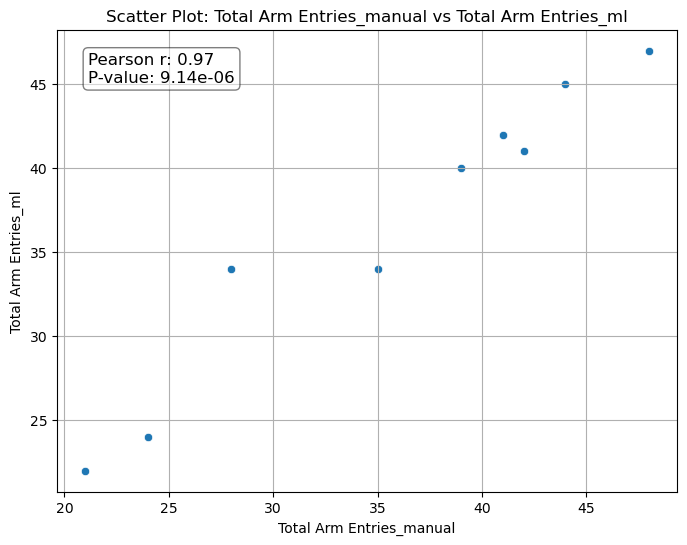

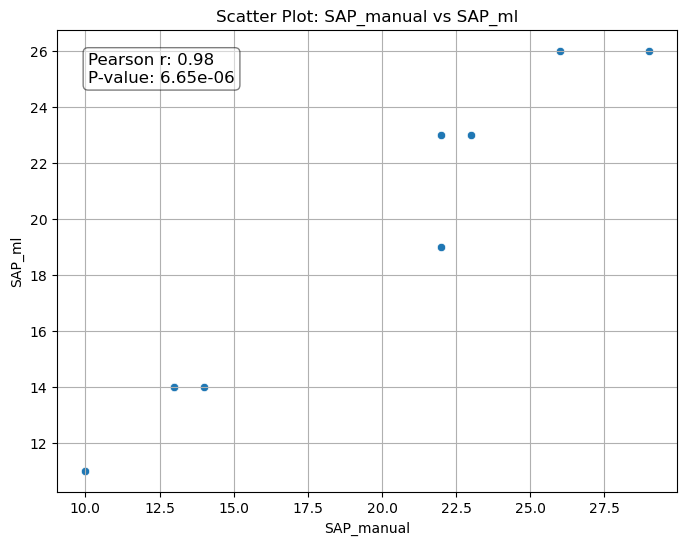

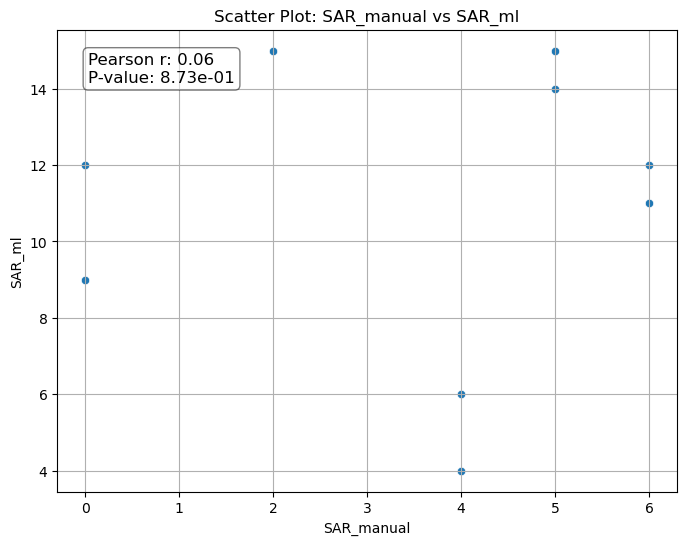

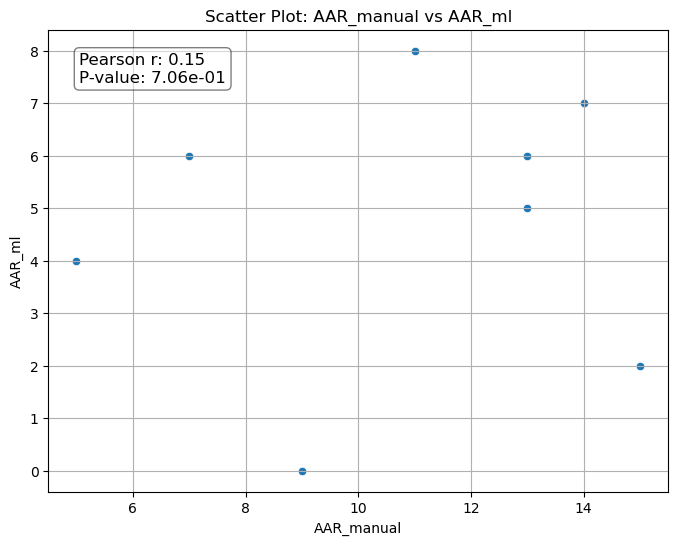

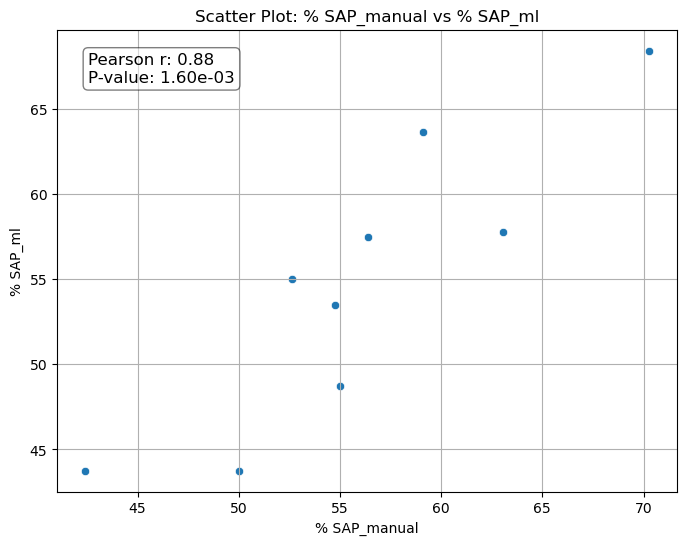

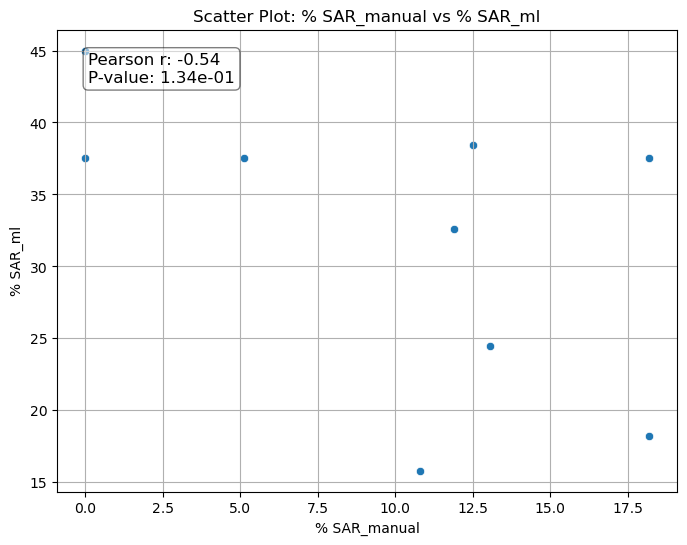

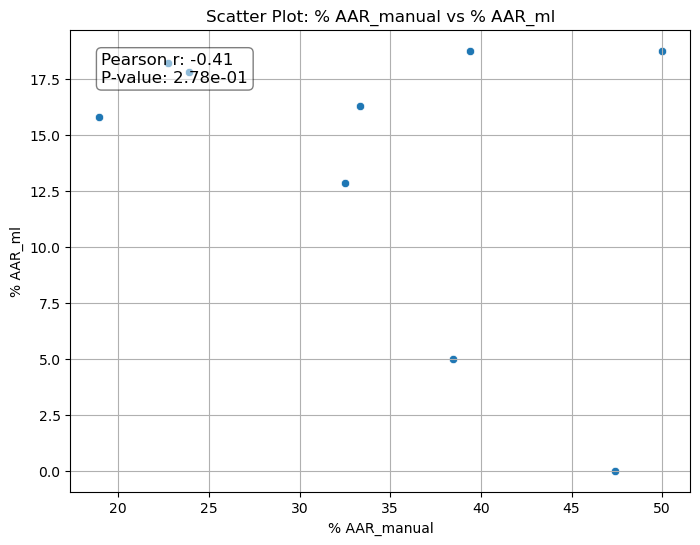

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


# Load the spreadsheet
# basepath = '/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/BehaviouralData/1.DataPresentationJul2023/NLF_NLGF_21mo_Analysis_GraphPad/'
# file_path = basepath + 'y_maze_results_MLvsManual_0.08.xlsx'
basepath = '/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/BehaviouralData/Angela/1.Angela Analysis 2024-2025/Y-maze/AdditionalAnalyses/'
file_path = basepath + 'y_maze_Manual_results_12moNLGF.xlsx'
xls = pd.ExcelFile(file_path)

# Read the manually annotated data (tab 0) and machine-learning data (tab 1)
manual_data = xls.parse(0)
ml_data = xls.parse(1)

# Ensure both tabs have a common column for experiment IDs (e.g., 'Experiment ID')
# Perform an inner join to keep only rows with matching experiment IDs
common_data = pd.merge(manual_data, ml_data, on='Experiment ID', suffixes=('_manual', '_ml'))

# Save the merged data to a new tab called 'Merged'
with pd.ExcelWriter(file_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    common_data.to_excel(writer, sheet_name='Merged', index=False)

# Check if the merged data is empty
if common_data.empty:
    print("The merged data is empty. Ensure both tabs have matching 'Experiment ID' values.")
else:
    # Calculate the correlation between manual and machine learning columns
    manual_columns = common_data.filter(like='_manual')
    ml_columns = common_data.filter(like='_ml')

    if manual_columns.empty or ml_columns.empty:
        print("No correlation could be calculated. Ensure the '_manual' and '_ml' columns exist and contain numeric data.")
    else:
        # Scatter plot for manual vs ML values with Pearson r and p-value
        for manual_col, ml_col in zip(manual_columns.columns, ml_columns.columns):
            # Calculate Pearson r and p-value
            r, p = pearsonr(common_data[manual_col], common_data[ml_col])

            # Create scatter plot
            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=common_data[manual_col], y=common_data[ml_col])
            plt.title(f"Scatter Plot: {manual_col} vs {ml_col}")
            plt.xlabel(manual_col)
            plt.ylabel(ml_col)

            # Annotate the plot with Pearson r and p-value
            plt.text(
                0.05, 0.95, f"Pearson r: {r:.2f}\nP-value: {p:.2e}",
                transform=plt.gca().transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
            )

            plt.grid(True)
            plt.show()

In [12]:
print(common_data.filter(like='_manual').isna().sum())
print(common_data.filter(like='_ml').isna().sum())

Total Arm Entries_manual    0
SAP_manual                  0
SAR_manual                  0
AAR_manual                  0
% SAP_manual                0
% SAR_manual                0
% AAR_manual                0
dtype: int64
Total Arm Entries_ml    0
SAP_ml                  0
SAR_ml                  0
AAR_ml                  0
% SAP_ml                0
% SAR_ml                0
% AAR_ml                0
dtype: int64


/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/openpyxl/reader/excel.py:237: UserWarning: Unknown extension is not supported and will be removed
  ws_parser.bind_all()
/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/openpyxl/reader/excel.py:237: UserWarning: Conditional Formatting extension is not supported and will be removed
  ws_parser.bind_all()


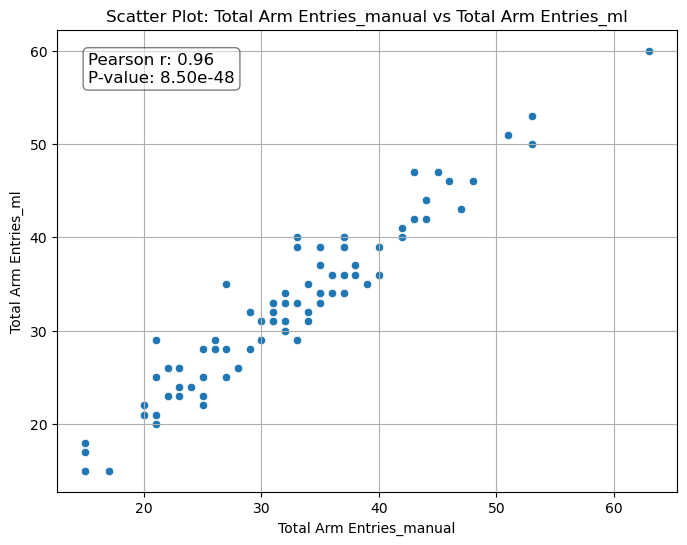

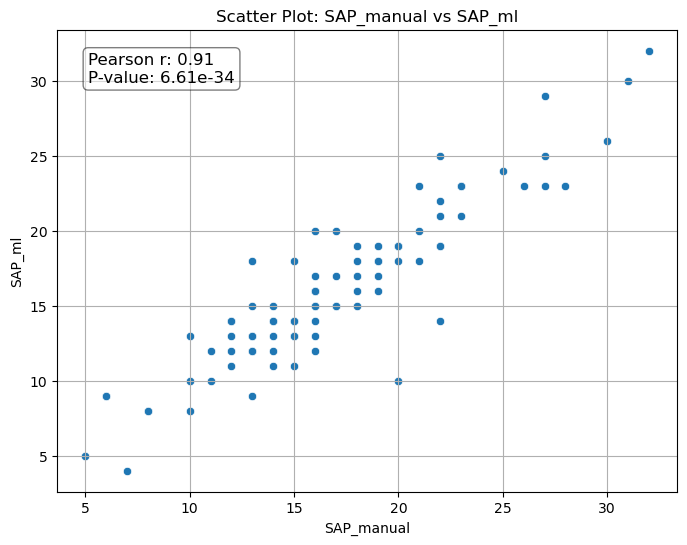

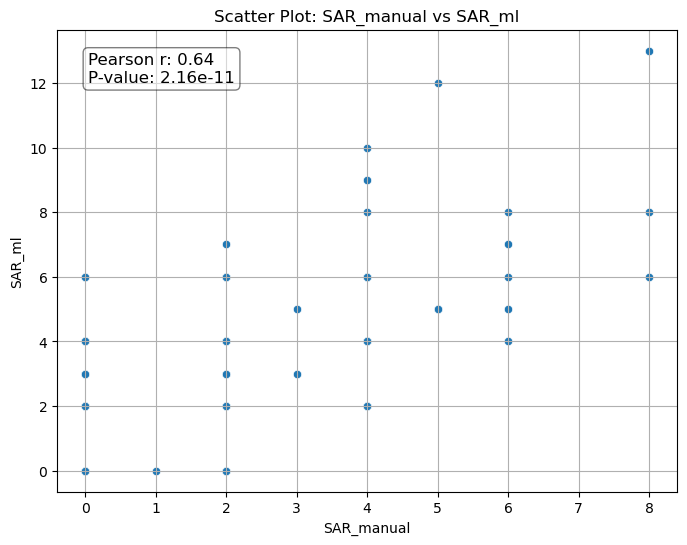

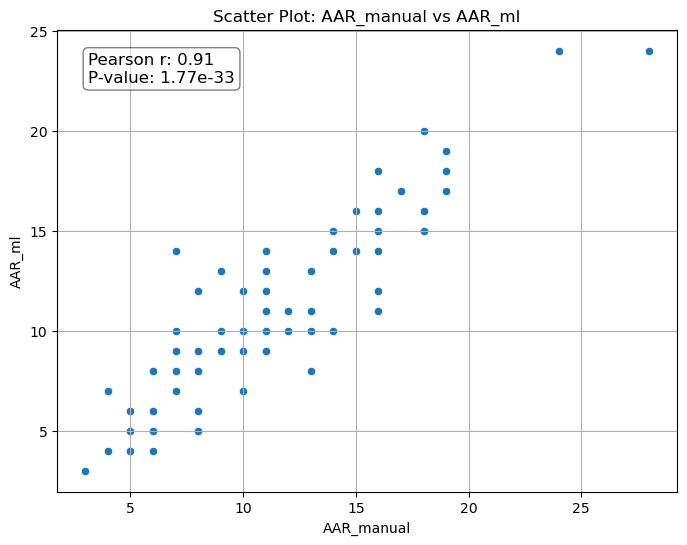

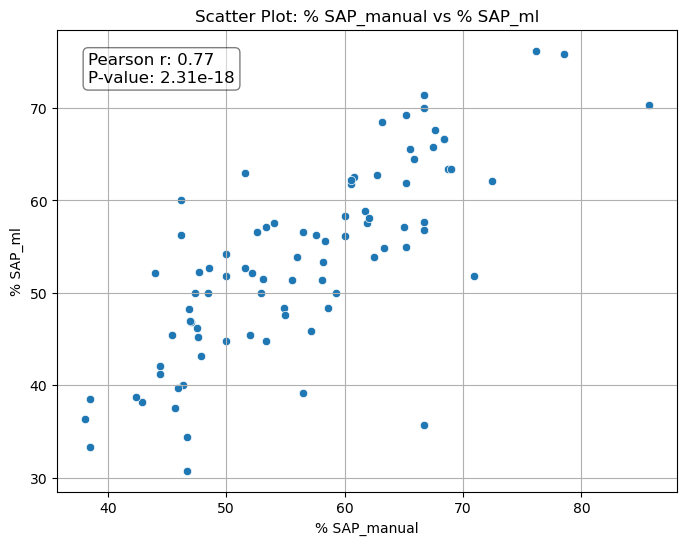

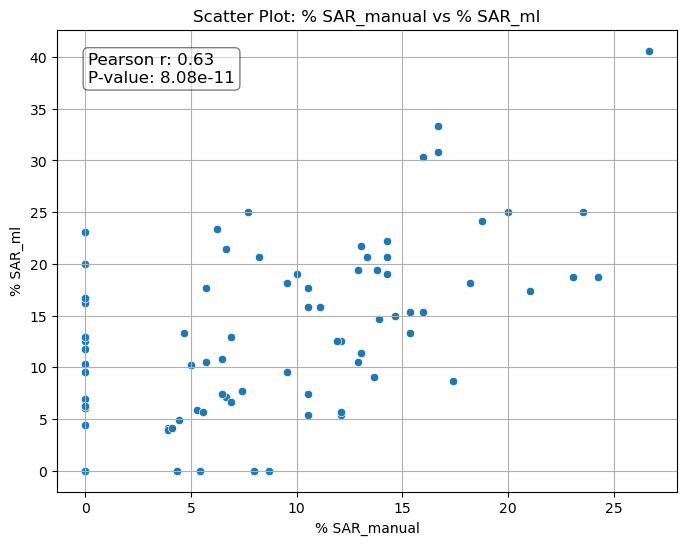

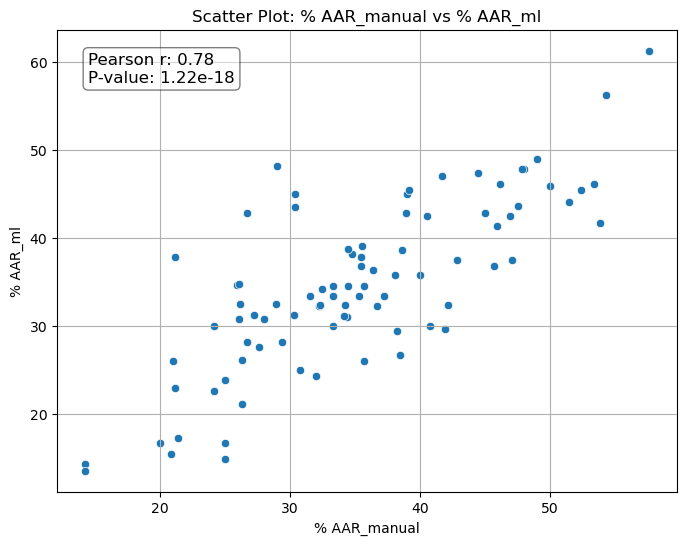

In [ ]:
### Tested diffeent thresholds of entry (changing the )


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from openpyxl import load_workbook

# Load the spreadsheet
basepath = '/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/BehaviouralData/1.DataPresentationJul2023/NLF_NLGF_21mo_Analysis_GraphPad/Y-maze_analysis_23032025/'
file_path = basepath + 'y_maze_results_MLvsManual_0.11.xlsx'
xls = pd.ExcelFile(file_path)

# Read the manually annotated data (tab 0) and machine-learning data (tab 1)
manual_data = xls.parse(0)
ml_data = xls.parse(1)

# Ensure both tabs have a common column for experiment IDs (e.g., 'Experiment ID')
# Perform an inner join to keep only rows with matching experiment IDs
common_data = pd.merge(manual_data, ml_data, on='Experiment ID', suffixes=('_manual', '_ml'))

# Save the merged data to a new tab called 'Merged'
with pd.ExcelWriter(file_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    common_data.to_excel(writer, sheet_name='Merged', index=False)

# Check if the merged data is empty
if common_data.empty:
    print("The merged data is empty. Ensure both tabs have matching 'Experiment ID' values.")
else:
    # Calculate the correlation between manual and machine learning columns
    manual_columns = common_data.filter(like='_manual')
    ml_columns = common_data.filter(like='_ml')

    if manual_columns.empty or ml_columns.empty:
        print("No correlation could be calculated. Ensure the '_manual' and '_ml' columns exist and contain numeric data.")
    else:
        # Scatter plot for manual vs ML values with Pearson r and p-value
        for manual_col, ml_col in zip(manual_columns.columns, ml_columns.columns):
            # Calculate Pearson r and p-value
            r, p = pearsonr(common_data[manual_col], common_data[ml_col])

            # Create scatter plot
            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=common_data[manual_col], y=common_data[ml_col])
            plt.title(f"Scatter Plot: {manual_col} vs {ml_col}")
            plt.xlabel(manual_col)
            plt.ylabel(ml_col)

            # Annotate the plot with Pearson r and p-value
            plt.text(
                0.05, 0.95, f"Pearson r: {r:.2f}\nP-value: {p:.2e}",
                transform=plt.gca().transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
            )

            plt.grid(True)
            plt.show()

In [16]:
# Extract IDs from tab 1 that do not exist in tab 0 to make sure you didn't miss any IDs
import pandas as pd

def extract_missing_ids(file_path, id_column='Experiment ID'):
    """
    Extract IDs from tab 1 that do not exist in tab 0 of the given spreadsheet.

    Parameters:
        file_path (str): Path to the Excel file.
        id_column (str): Name of the column containing the IDs (default is 'Experiment ID').

    Returns:
        list: A list of IDs from tab 1 that are not in tab 0.
    """
    # Load the spreadsheet
    xls = pd.ExcelFile(file_path)

    # Read tab 0 and tab 1
    tab_0 = xls.parse(0)
    tab_1 = xls.parse(1)

    # Extract IDs from both tabs
    ids_tab_0 = set(tab_0[id_column])
    ids_tab_1 = set(tab_1[id_column])

    # Find IDs in tab 1 that are not in tab 0
    missing_ids = ids_tab_1 - ids_tab_0

    return list(missing_ids)

# Example usage
basepath = '/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/BehaviouralData/Angela/1.Angela Analysis 2024-2025/Y-maze/AdditionalAnalyses/'
file_path = basepath + 'y_maze_Manual_results_12moNLGF.xlsx'
missing_ids = extract_missing_ids(file_path)
print(len(missing_ids))
print("IDs in tab 1 that are not in tab 0:", missing_ids)

102
IDs in tab 1 that are not in tab 0: [1119507, 1119508, 1119511, 1120023, 1119001, 1119002, 1120027, 1120807, 1119788, 1119789, 1121069, 1121070, 1121072, 1121073, 1119794, 1121074, 1118778, 1118779, 1118780, 1119036, 1118783, 1118784, 1118785, 1118786, 1118787, 1118790, 1118791, 1119039, 1118793, 1118794, 1118795, 1118796, 1119560, 1120072, 1119050, 1120073, 1120075, 1119565, 1119060, 1120874, 1120875, 1120876, 1120877, '1119636b', 1120880, 1120881, 1120882, 1121141, 1121142, 1120891, 1119628, 1119630, 1119631, 1119632, 1119633, 1119637, 1120151, '1119510b', 1119389, 1119390, 1119391, 1119392, 1118881, 1118882, 1118883, 1120157, 1120158, 1120159, 1119143, 1119144, 1119145, 1119146, 1119147, 1119148, 1119149, 1120170, 1119663, 1120175, 1119155, 1119156, 1120949, 1120950, 1120951, 1119157, 1119160, 1120968, 1120969, 1119691, 1119181, 1119185, 1119959, 1119040, 1119041, 1119042, 1119464, 1119723, 1119724, 1119737, 1119994, 1119996, 1119741, 1119743]


In [17]:
import pandas as pd

def merge_tabs_with_genotypes(file_path, id_column='Experiment ID', output_tab_name='DataWithGenotypes'):
    """
    Merge tab 0 and tab 2 based on a common ID column and save the result in a new tab.

    Parameters:
        file_path (str): Path to the Excel file.
        id_column (str): Name of the column containing the IDs (default is 'Experiment ID').
        output_tab_name (str): Name of the new tab to save the merged data (default is 'DataWithGenotypes').

    Returns:
        None
    """
    # Load the spreadsheet
    xls = pd.ExcelFile(file_path)

    # Read tab 0 and tab 2
    tab_0 = xls.parse(0)
    tab_2 = xls.parse(2)

    # Merge the two tabs based on the common ID column
    merged_data = pd.merge(tab_0, tab_2, on=id_column, how='inner', suffixes=('_data', '_info'))

    # Save the merged data to a new tab in the same Excel file
    with pd.ExcelWriter(file_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
        merged_data.to_excel(writer, sheet_name=output_tab_name, index=False)

    print(f"Merged data saved to tab '{output_tab_name}' in the Excel file.")

# Example usage
basepath = '/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/BehaviouralData/Angela/1.Angela Analysis 2024-2025/Y-maze/AdditionalAnalyses/'
file_path = basepath + 'y_maze_Manual_results_12moNLGF.xlsx'
merge_tabs_with_genotypes(file_path)

Merged data saved to tab 'DataWithGenotypes' in the Excel file.
